In [1]:
# Basic Libraries
import numpy as np
import pandas as pd
import seaborn as sb
import matplotlib.pyplot as plt # we only need pyplot
sb.set() # set the default Seaborn style for graphics

In [4]:
bldgdata = pd.read_csv('train.csv')
bldgdata.head(10)

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000
5,6,50,RL,85.0,14115,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,MnPrv,Shed,700,10,2009,WD,Normal,143000
6,7,20,RL,75.0,10084,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,8,2007,WD,Normal,307000
7,8,60,RL,NaN,10382,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,Shed,350,11,2009,WD,Normal,200000
8,9,50,RM,51.0,6120,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,4,2008,WD,Abnorml,129900
9,10,190,RL,50.0,7420,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,1,2008,WD,Normal,118000


overallQual, overallCond

In [5]:
bldgdata.dtypes

Id                 int64
MSSubClass         int64
MSZoning          object
LotFrontage      float64
LotArea            int64
                  ...   
MoSold             int64
YrSold             int64
SaleType          object
SaleCondition     object
SalePrice          int64
Length: 81, dtype: object

In [16]:
sale_price = pd.DataFrame(bldgdata['SalePrice'])
sale_price_series = sale_price['SalePrice']

In [47]:
# Keep only numeric variables (int64 and float64)
numeric_data = bldgdata.select_dtypes(include=['number'])

numeric_data.head()

,Id,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,...,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SalePrice
0,1,60,65.0,8450,7,5,2003,2003,196.0,706,...,0,61,0,0,0,0,0,2,2008,208500
1,2,20,80.0,9600,6,8,1976,1976,0.0,978,...,298,0,0,0,0,0,0,5,2007,181500
2,3,60,68.0,11250,7,5,2001,2002,162.0,486,...,0,42,0,0,0,0,0,9,2008,223500
3,4,70,60.0,9550,7,5,1915,1970,0.0,216,...,0,35,272,0,0,0,0,2,2006,140000
4,5,60,84.0,14260,8,5,2000,2000,350.0,655,...,192,84,0,0,0,0,0,12,2008,250000


In [20]:
sale_price.describe()

,SalePrice
count,1460.000000
mean,180921.195890
std,79442.502883
min,34900.000000
25%,129975.000000
50%,163000.000000
75%,214000.000000
max,755000.000000


<Axes: >

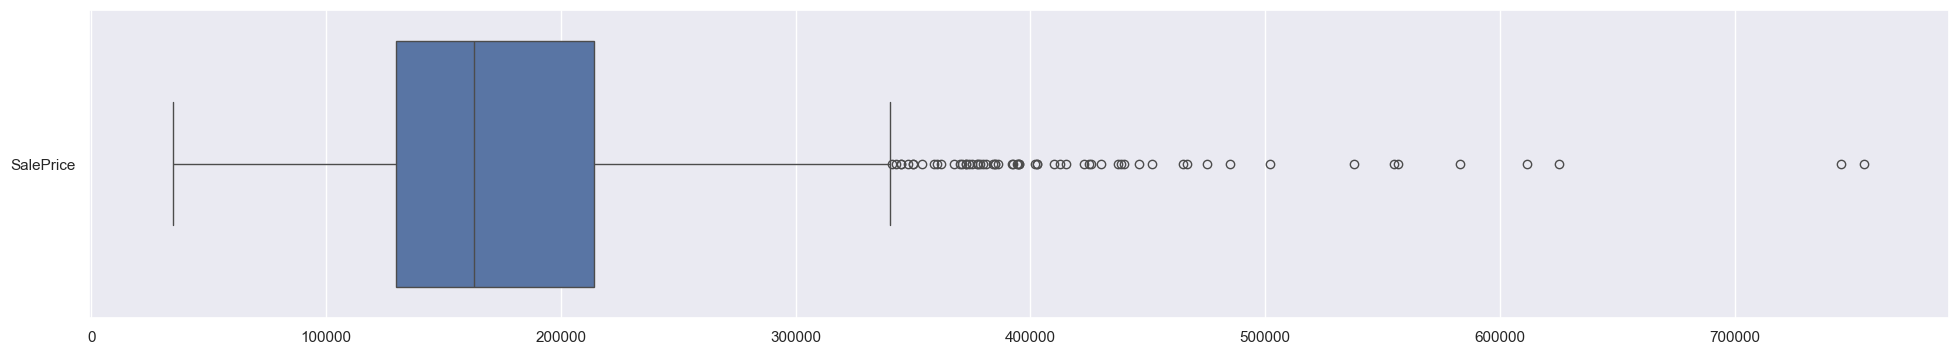

In [26]:
f, axes = plt.subplots(1, 1, figsize=(24, 4))
sb.boxplot(data=sale_price, orient = "h")

<Axes: ylabel='Count'>

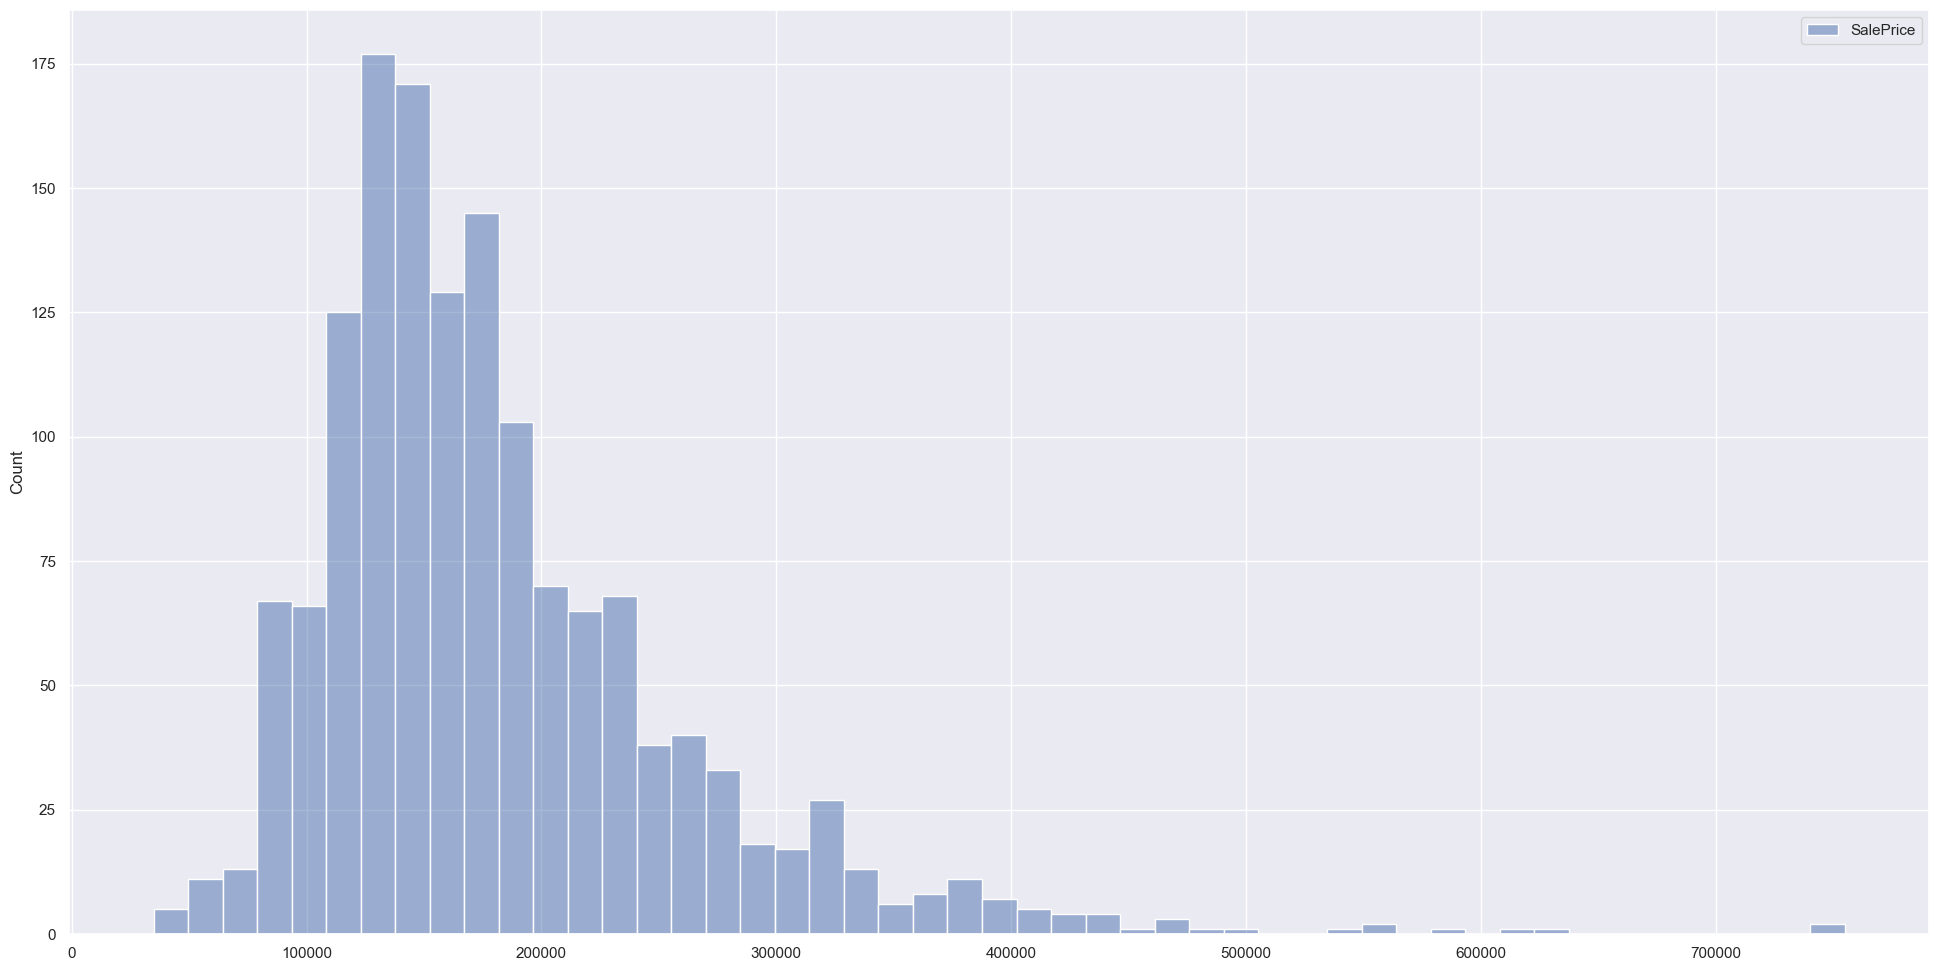

In [28]:
f, axes = plt.subplots(1, 1, figsize=(24, 12))
sb.histplot(data=sale_price, kde=False)

<Axes: ylabel='Density'>

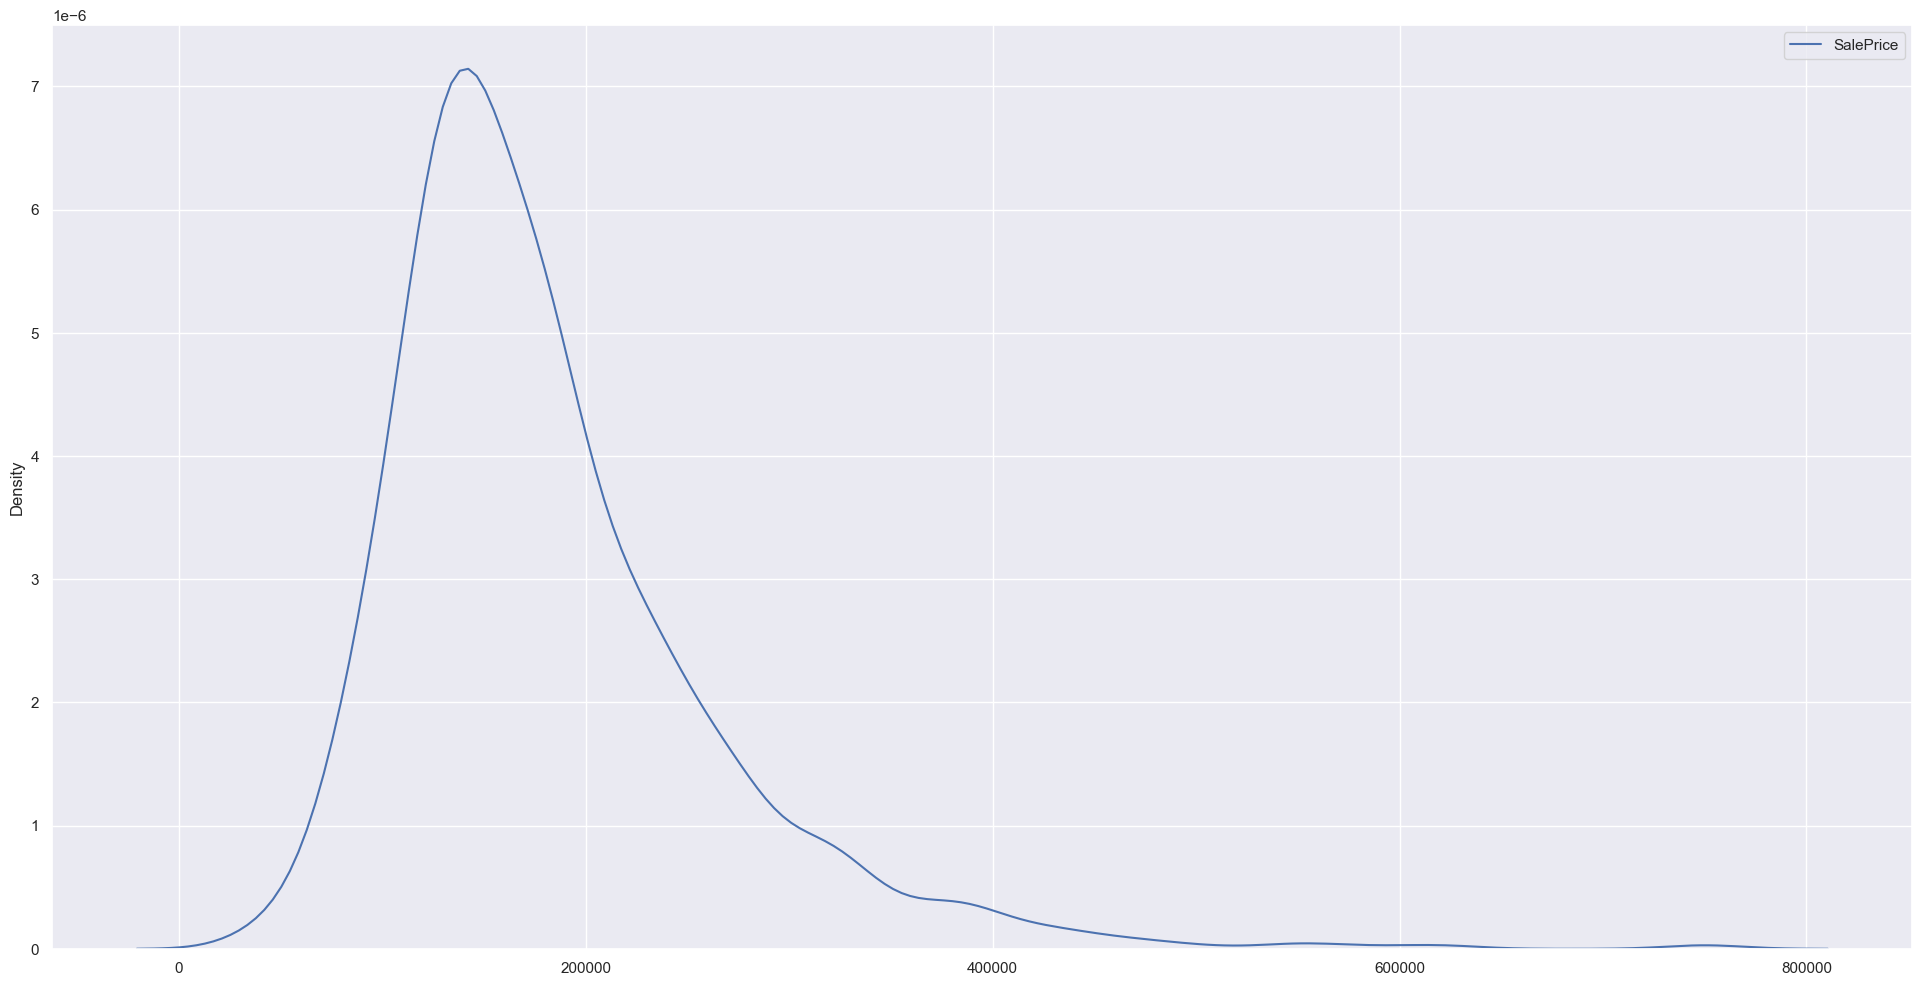

In [30]:
f, axes = plt.subplots(1, 1, figsize=(24, 12))
sb.kdeplot (data=sale_price, color = 'blue')

In [33]:
lot_area = pd.DataFrame(bldgdata['LotArea'])
lot_area_series = lot_area['LotArea']

In [34]:
lot_area.describe()

,LotArea
count,1460.000000
mean,10516.828082
std,9981.264932
min,1300.000000
25%,7553.500000
50%,9478.500000
75%,11601.500000
max,215245.000000


<Axes: >

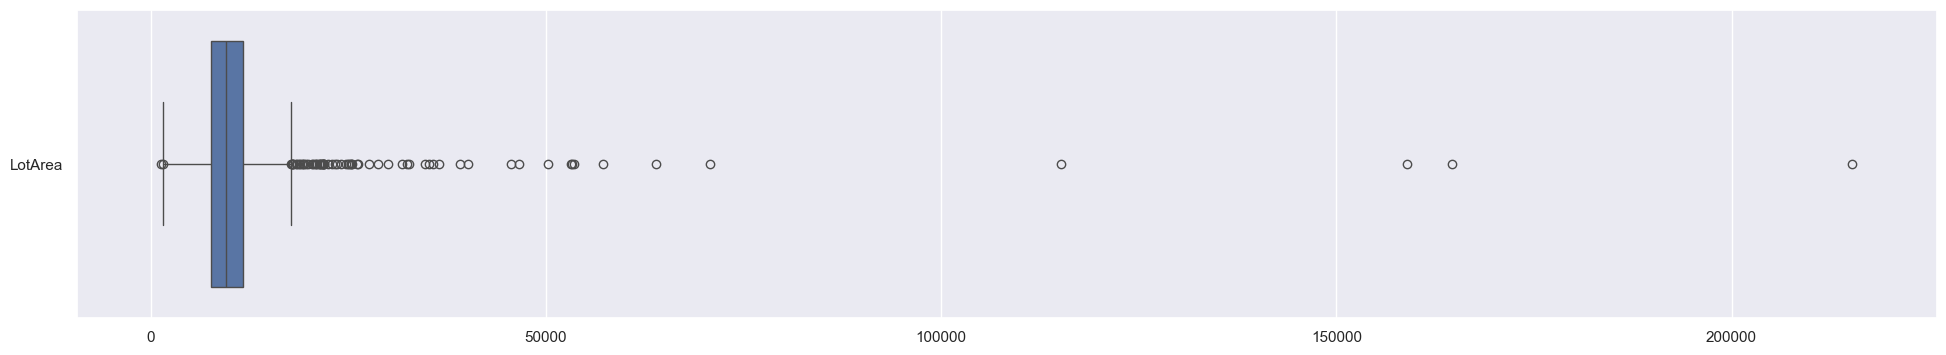

In [35]:
f, axes = plt.subplots(1, 1, figsize=(24, 4))
sb.boxplot(data=lot_area, orient = "h")

<Axes: ylabel='Count'>

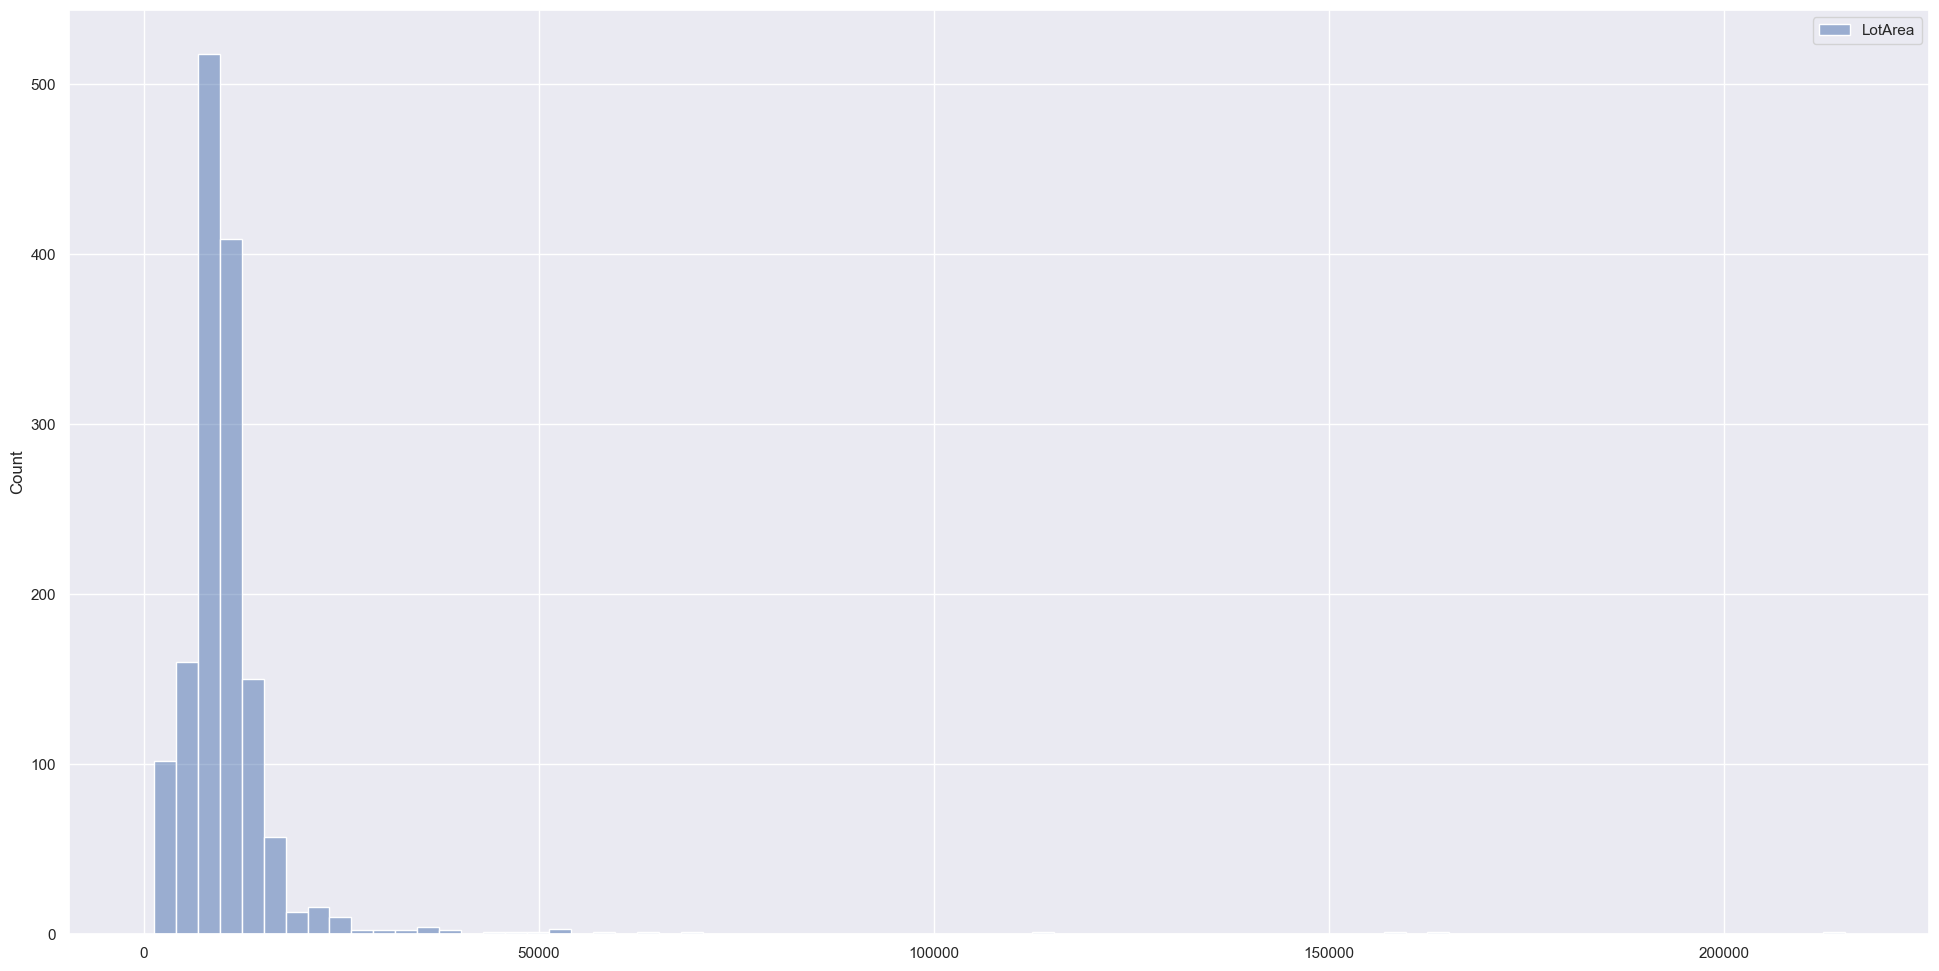

In [37]:
f, axes = plt.subplots(1, 1, figsize=(24, 12))
sb.histplot(data=lot_area, kde=False)

<Axes: ylabel='Density'>

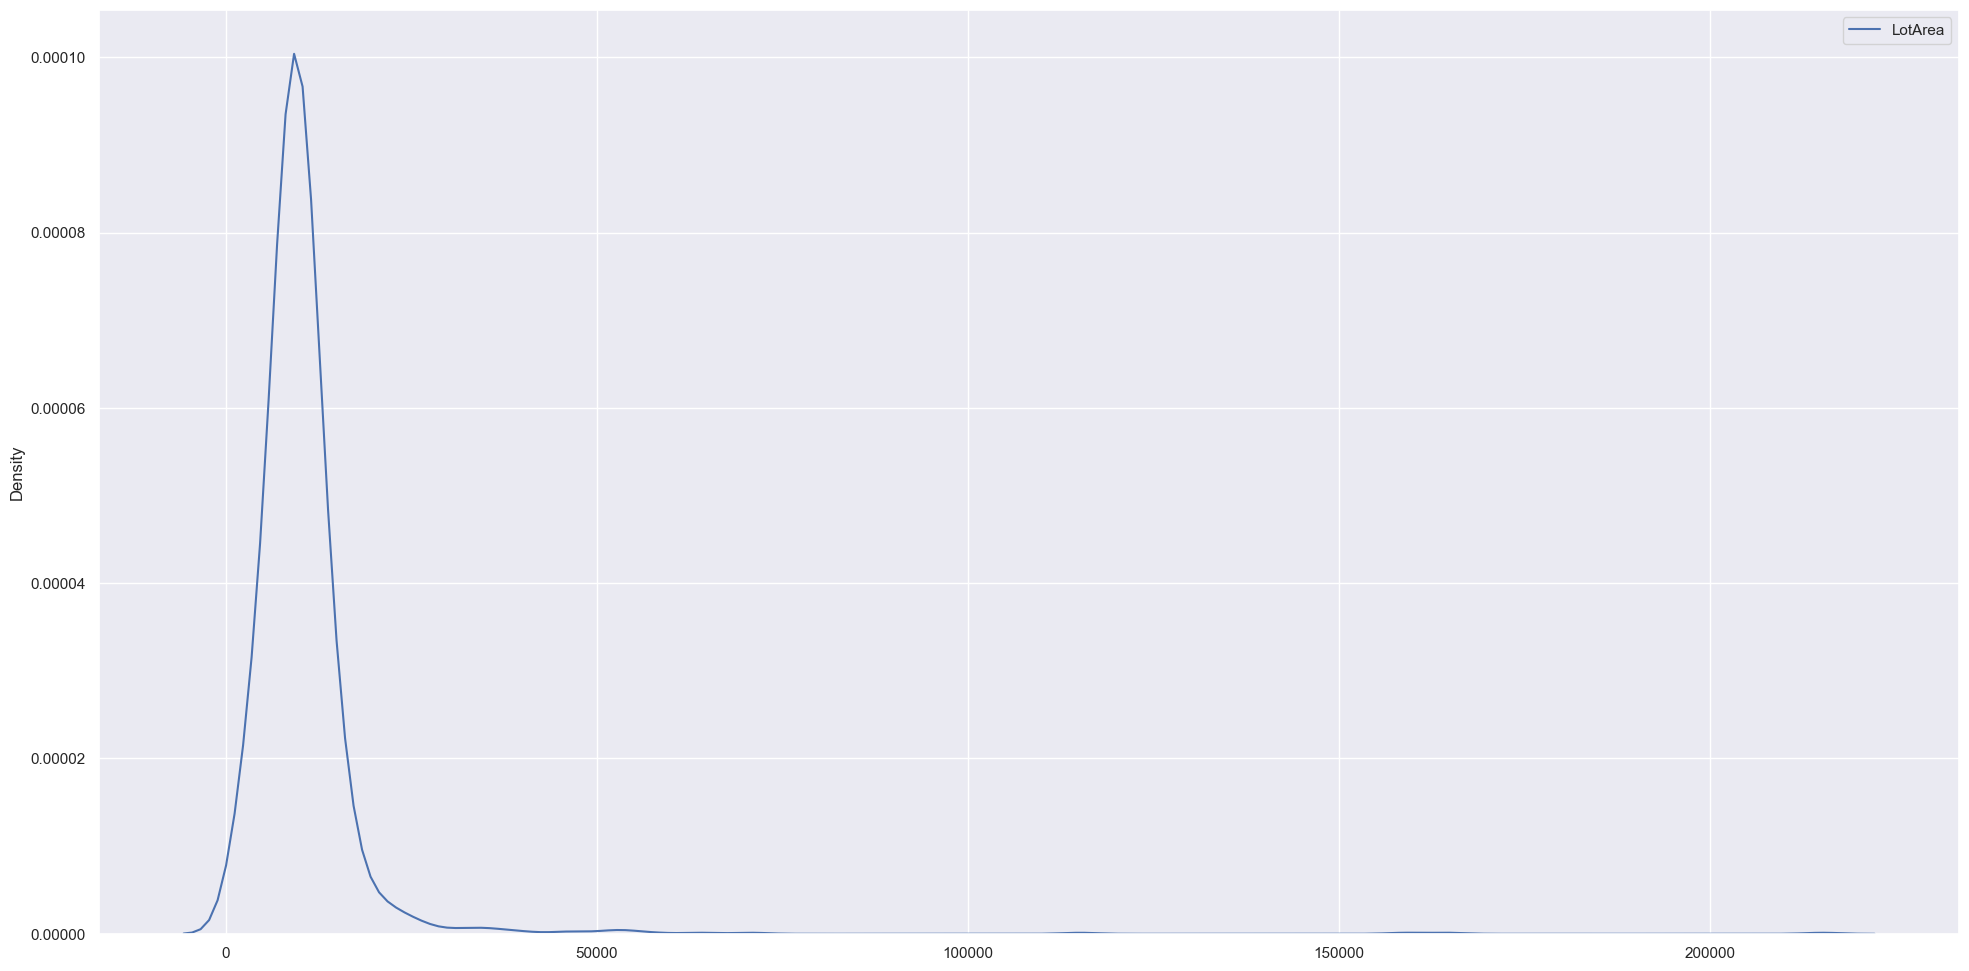

In [39]:
f, axes = plt.subplots(1, 1, figsize=(24, 12))
sb.kdeplot (data=lot_area, color = 'blue')

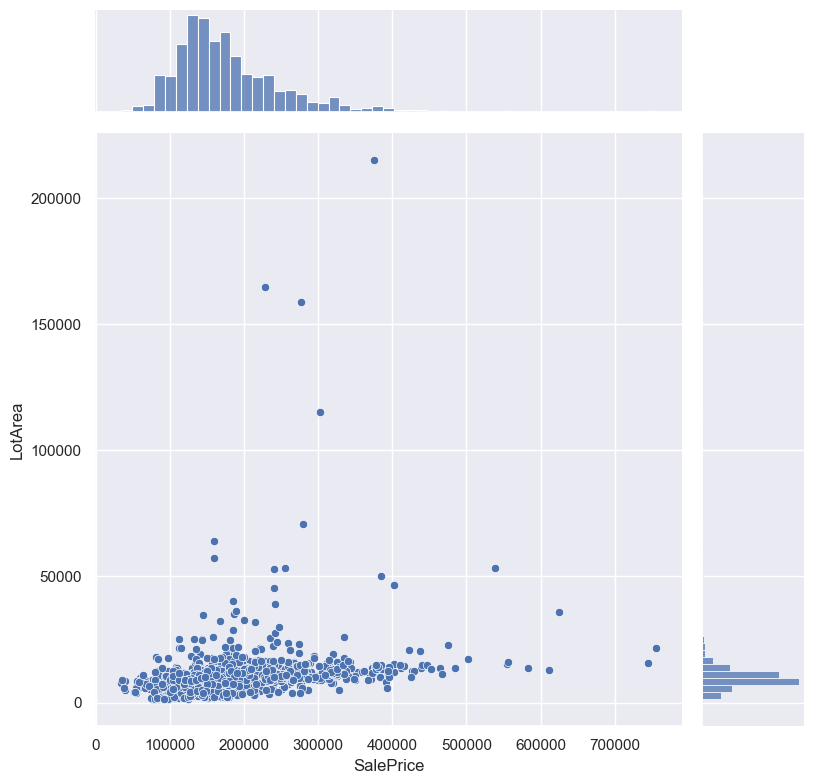

In [41]:
sb.jointplot(x = sale_price_series, y = lot_area_series, height = 8)

In [46]:
# Create a joint dataframe by concatenating the two variables
jointDF = pd.concat([sale_price, lot_area], axis = 1,join='inner')
print(jointDF)
# Calculate the correlation between the two columns/variables
corrmat = jointDF.corr()
print(corrmat)

      SalePrice  LotArea
0        208500     8450
1        181500     9600
2        223500    11250
3        140000     9550
4        250000    14260
...         ...      ...
1455     175000     7917
1456     210000    13175
1457     266500     9042
1458     142125     9717
1459     147500     9937

[1460 rows x 2 columns]
           SalePrice   LotArea
SalePrice   1.000000  0.263843
LotArea     0.263843  1.000000


<Axes: >

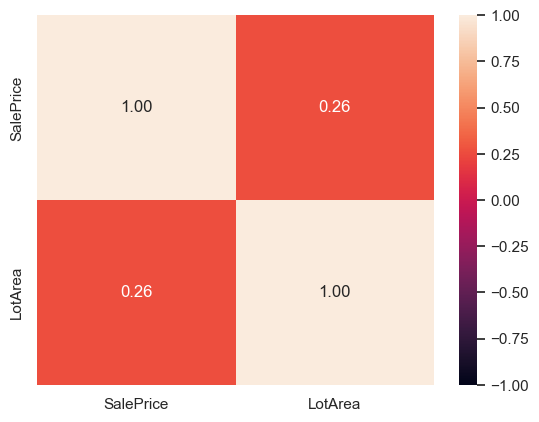

In [45]:
sb.heatmap(corrmat, vmin = -1, vmax = 1, annot = True, fmt=".2f")